# Analisi NLP su Report di Food Insecurity

### 1. Setup, Importazioni e Caricamento Dati


In [1]:
from google.colab import drive
import os
import re
import pandas as pd
import numpy as np
import spacy
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import ipywidgets as widgets
from IPython.display import display, clear_output

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Inizializzazione Google Drive
try:
    drive.mount('/content/drive')
except:
    pass

TESTO_DIR = "/content/drive/MyDrive/HERO/key_results_testi"

# Verifica e carica il modello spaCy
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    import os
    os.system("python -m spacy download en_core_web_sm")
    nlp = spacy.load('en_core_web_sm')


Mounted at /content/drive


In [2]:
# ============================================================
# FUNZIONE: ESTRAI METADATA DAL NOME FILE
# ============================================================
def estrai_metadata(nome_file):
    base = nome_file.replace("_KeyResults.txt", "")
    periodo_match = re.search(r'([A-Za-z]{3}_\d{4})_-_([A-Za-z]{3}_\d{4})', base)

    if periodo_match:
        inizio_periodo = periodo_match.group(1).replace('_', ' ')
        fine_periodo = periodo_match.group(2).replace('_', ' ')
        periodo = f"{inizio_periodo} / {fine_periodo}"
    else:
        inizio_periodo = None
        fine_periodo = None
        periodo = base

    paese_match = re.match(r'^(.+?)_[A-Za-z]{3}_\d{4}', base)
    paese = paese_match.group(1).replace('_', ' ') if paese_match else base

    return {
        "paese": paese,
        "periodo": periodo,
        "inizio_periodo": inizio_periodo,
        "fine_periodo": fine_periodo,
        "nome_file": nome_file
    }

def extract_years_from_period(period_string):
    years = re.findall(r'\d{4}', period_string)
    return [int(year) for year in years]

documents_data = []

# Fallback in caso la cartella Drive non esista (esecuzione locale)
if not os.path.exists(TESTO_DIR):
    TESTO_DIR = "key_results_testi"

if os.path.exists(TESTO_DIR):
    for filename in os.listdir(TESTO_DIR):
        file_path = os.path.join(TESTO_DIR, filename)
        if os.path.isfile(file_path) and filename.endswith('.txt'):
            try:
                metadata = estrai_metadata(filename)
                with open(file_path, 'r', encoding='utf-8') as f:
                    file_content = f.read()
                    documents_data.append({
                        'filename': filename,
                        'country': metadata['paese'],
                        'period': metadata['periodo'],
                        'text': file_content
                    })
            except Exception as e:
                print(f"Error reading {filename}: {e}")

df_documents = pd.DataFrame(documents_data)
if not df_documents.empty:
    df_documents['years_in_period'] = df_documents['period'].apply(extract_years_from_period)

print(f"Total documents loaded into DataFrame: {len(df_documents)}")
display(df_documents.head())


Total documents loaded into DataFrame: 497


,filename,country,period,text,years_in_period
0,Democratic_Republic_of_the_Congo_Dec_2012_-_De...,Democratic Republic of the Congo,Dec 2012 / Dec 2012,COUNTRY: Democratic Republic of the Congo\nPER...,"[2012, 2012]"
1,Burundi_Nov_2024_-_Mar_2025_KeyResults.txt,Burundi,Nov 2024 / Mar 2025,COUNTRY: Burundi\nPERIOD: Nov 2024 / Mar 2025\...,"[2024, 2025]"
2,Madagascar_Aug_2017_-_Mar_2018_KeyResults.txt,Madagascar,Aug 2017 / Mar 2018,COUNTRY: Madagascar\nPERIOD: Aug 2017 / Mar 20...,"[2017, 2018]"
3,Yemen_Oct_2023_-_Feb_2024_KeyResults.txt,Yemen,Oct 2023 / Feb 2024,COUNTRY: Yemen\nPERIOD: Oct 2023 / Feb 2024\n=...,"[2023, 2024]"
4,Mozambique_Apr_2018_-_Sep_2018_KeyResults.txt,Mozambique,Apr 2018 / Sep 2018,COUNTRY: Mozambique\nPERIOD: Apr 2018 / Sep 20...,"[2018, 2018]"


### 2. Definizione Stopwords (Custom + Entità Geografiche)


In [15]:
# 1. Stopword Manuali/Dominio
custom_stopwords = {'ipc', 'phase', 'million', 'country', 'level', 'percent', 'classify', 'area', 'analysis', 'period', 'season', 'state',
                    'analysed', 'projection', 'region', 'current', 'number', 'total', 'likely', 'province','factor', 'main', 'result', 'zone'}

# 2. Stopword basate su Entità Geografiche e Temporali (NER)
GEO_TEMPORAL_ENTITY_LABELS = ['GPE', 'LOC', 'DATE', 'TIME']
ner_based_stopwords = set()

print("Identificazione di stopword basate su entità geografiche e temporali...")
if not df_documents.empty:
    for doc_text in df_documents['text']:
        doc = nlp(doc_text)
        for ent in doc.ents:
            if ent.label_ in GEO_TEMPORAL_ENTITY_LABELS:
                ner_based_stopwords.add(ent.lemma_.lower())

# Combinazione Finale Stopwords
final_stopwords = custom_stopwords.union(ner_based_stopwords)

print(f"Numero totale di custom stopword (manuali + NER): {len(final_stopwords)}")


Identificazione di stopword basate su entità geografiche e temporali...
Numero totale di custom stopword (manuali + NER): 2282


### 3. Preprocessing del Testo (Estrazione Unigrammi e Bigrammi)


In [16]:
top_unigrams_per_doc = []
full_unigram_counts_per_doc = []
preprocessed_texts = []
top_bigrams_per_doc = []

all_unigrams_filtered = []
all_bigrams_filtered = []

if not df_documents.empty:
    for index, row in df_documents.iterrows():
        doc_text = row['text']
        doc = nlp(doc_text)

        # Filtro POS (Solo Nomi e Aggettivi) e Stopword
        filtered_lemmas = [
            token.lemma_.lower()
            for token in doc
            if not token.is_stop and not token.is_punct and token.is_alpha
            and token.lemma_.lower() not in final_stopwords
            and token.pos_ in ['NOUN', 'ADJ']
        ]

        all_unigrams_filtered.extend(filtered_lemmas)

        unigram_counts = Counter(filtered_lemmas)
        top_unigrams_per_doc.append(unigram_counts.most_common(10))
        full_unigram_counts_per_doc.append(dict(unigram_counts))
        preprocessed_texts.append(' '.join(filtered_lemmas))

        # Generazione Bigrammi
        bigrams_for_doc = [
            f"{filtered_lemmas[i]} {filtered_lemmas[i+1]}"
            for i in range(len(filtered_lemmas) - 1)
        ]
        all_bigrams_filtered.extend(bigrams_for_doc)

        bigram_counts = Counter(bigrams_for_doc)
        top_bigrams_per_doc.append(bigram_counts.most_common(10))

    df_documents['top_unigrams_per_doc'] = top_unigrams_per_doc
    df_documents['unigram_counts'] = full_unigram_counts_per_doc
    df_documents['preprocessed_text'] = preprocessed_texts
    df_documents['top_bigrams_per_doc'] = top_bigrams_per_doc

print("Estrazione completata. Calcolo Frequenze Globali...")

unigram_counts_filtered = Counter(all_unigrams_filtered)
bigram_counts_filtered = Counter(all_bigrams_filtered)

print("\n--- 20 parole (unigrammi) più comuni ---")
for word, count in unigram_counts_filtered.most_common(20):
    print(f"{word}: {count}")

print("\n--- 20 bigrammi più comuni ---")
for bigram, count in bigram_counts_filtered.most_common(20):
    print(f"{bigram}: {count}")


Estrazione completata. Calcolo Frequenze Globali...

--- 20 parole (unigrammi) più comuni ---
food: 3145
people: 1817
population: 1526
insecurity: 1173
high: 935
acute: 828
situation: 727
household: 723
price: 525
district: 523
livelihood: 484
security: 440
access: 399
emergency: 389
poor: 377
production: 348
humanitarian: 345
harvest: 318
crop: 317
assistance: 313

--- 20 bigrammi più comuni ---
food insecurity: 1068
acute food: 656
people population: 437
food security: 392
high acute: 359
population people: 236
food price: 221
food consumption: 195
security situation: 184
population high: 181
insecurity people: 170
people high: 165
people people: 156
acute malnutrition: 155
humanitarian assistance: 140
high food: 139
food insecure: 122
access food: 120
people emergency: 119
household food: 109


### 4. Analisi Esplorativa e Visualizzazioni


/tmp/ipykernel_918/1642876280.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=df_top_unigrams, palette='viridis')


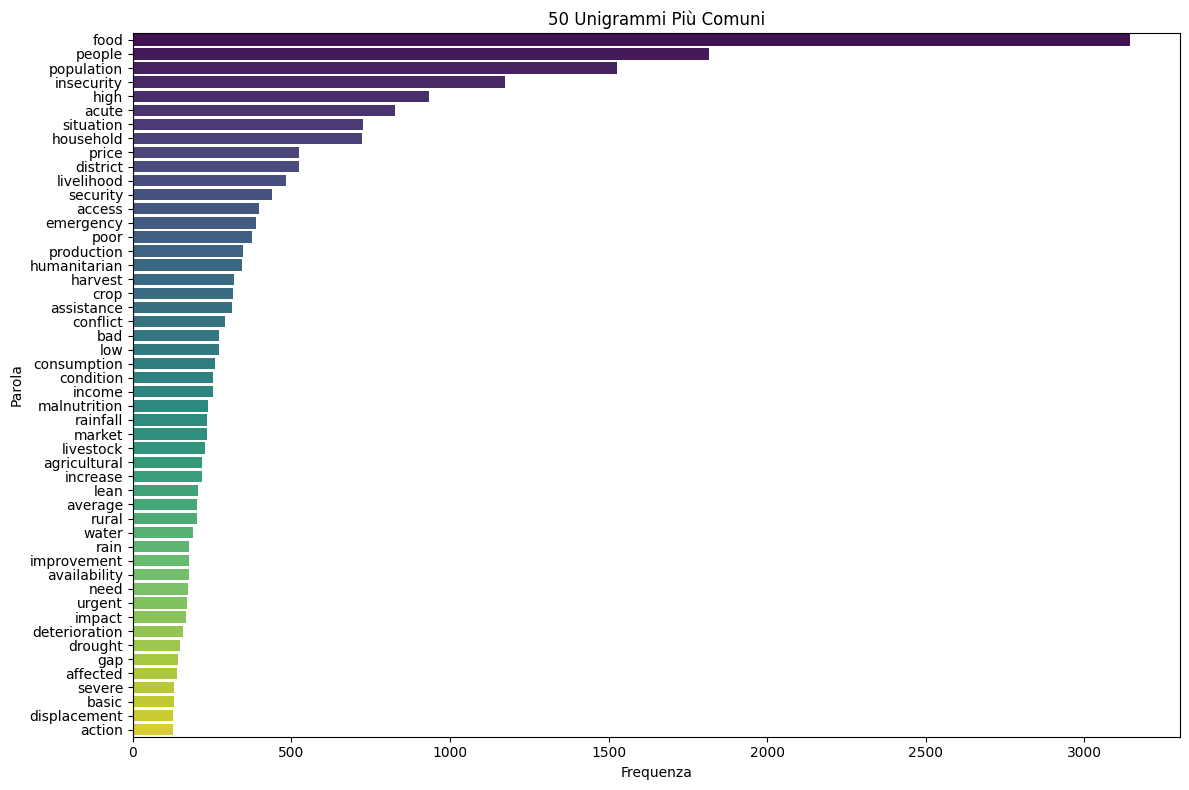

In [17]:
# Grafico a Barre degli Unigrammi Più Comuni
if unigram_counts_filtered:
    top_50_unigrams = unigram_counts_filtered.most_common(50)
    df_top_unigrams = pd.DataFrame(top_50_unigrams, columns=['Word', 'Frequency'])

    fig = plt.figure(figsize=(12, 8))
    sns.barplot(x='Frequency', y='Word', data=df_top_unigrams, palette='viridis')
    plt.title('50 Unigrammi Più Comuni')
    plt.xlabel('Frequenza')
    plt.ylabel('Parola')
    plt.tight_layout()
    plt.show()


In [ ]:
# Word Cloud Globale Statica (Top 100 parole)
print("--- Word Cloud Globale Statica (Top 100 parole) ---")
if 'unigram_counts_filtered' in globals() and unigram_counts_filtered:
    wordcloud_global = WordCloud(width=1000, height=500, background_color='white', random_state=42).generate_from_frequencies(dict(unigram_counts_filtered.most_common(100)))
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud_global, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud Globale - Tutti i Paesi e Tutti gli Anni')
    plt.show()


In [19]:
# Word Cloud Interattiva
def generate_wordcloud_for_country_and_year(country_name, selected_year):
    filtered_docs = df_documents
    if country_name != 'Tutti i Paesi':
        filtered_docs = filtered_docs[filtered_docs['country'] == country_name]
    if selected_year != 0:
        filtered_docs = filtered_docs[filtered_docs['years_in_period'].apply(lambda y_list: selected_year in y_list)]

    if filtered_docs.empty:
        print(f"Nessun documento trovato per '{country_name}' e anno '{selected_year}'.")
        return

    cloud_counts = Counter()
    for counts_dict in filtered_docs['unigram_counts']:
        cloud_counts.update(counts_dict)
    if not cloud_counts:
        print("Nessuna parola trovata.")
        return

    wordcloud = WordCloud(width=800, height=400, background_color='white', random_state=42).generate_from_frequencies(dict(cloud_counts.most_common(50)))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud - {country_name} ({selected_year if selected_year != 0 else "Tutti gli Anni"})')
    plt.show()

countries_options = ['Tutti i Paesi']
if not df_documents.empty:
    countries_options += sorted(df_documents['country'].unique().tolist())

country_selector_new = widgets.Dropdown(options=countries_options, value='Tutti i Paesi', description='Paese:')
year_selector = widgets.SelectionSlider(options=[0], value=0, description='Anno:', continuous_update=False)

def _update_year_slider(selected_country):
    if df_documents.empty:
        return

    if selected_country == 'Tutti i Paesi':
        available_years = sorted(list(set(y for years in df_documents['years_in_period'] for y in years)))
    else:
        available_years = sorted(list(set(y for years in df_documents[df_documents['country'] == selected_country]['years_in_period'] for y in years)))

    if available_years:
        year_selector.options = [0] + available_years
        year_selector.disabled = False
    else:
        year_selector.options = [0]
        year_selector.value = 0
        year_selector.disabled = True

def _on_country_change(change):
    _update_year_slider(change.new)

country_selector_new.observe(_on_country_change, names='value')
_update_year_slider(country_selector_new.value)

out = widgets.interactive_output(generate_wordcloud_for_country_and_year, {'country_name': country_selector_new, 'selected_year': year_selector})
display(widgets.VBox([widgets.Label("Word Cloud Interattiva (0 = Tutti gli Anni)"), country_selector_new, year_selector, out]))


### 5. Estrazione Feature: TF-IDF e LSA (TruncatedSVD)


In [ ]:
# Utilizziamo direttamente il testo già pre-processato salvato nel dataframe
# Questo evita di dover far girare di nuovo il pesantissimo modello spaCy!

if 'preprocessed_text' in df_documents.columns:
    preprocessed_docs_for_tfidf = df_documents['preprocessed_text'].tolist()
else:
    print("ERRORE: Esegui prima la cella di Preprocessing!")
    preprocessed_docs_for_tfidf = []

# TfidfVectorizer (top 1000 features)
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=lambda text: text.split(),
    lowercase=False,
    max_features=1000
)

tfidf_matrix = tfidf_vectorizer.fit_transform(preprocessed_docs_for_tfidf)
print(f"Matrice TF-IDF originale: {tfidf_matrix.shape}")

# TruncatedSVD a 10 dimensioni
svd = TruncatedSVD(n_components=10, random_state=42)
tfidf_svd_matrix = svd.fit_transform(tfidf_matrix)
print(f"Matrice ridotta (LSA): {tfidf_svd_matrix.shape}")

svd_columns = [f'SVD_{i}' for i in range(10)]
df_tfidf_svd = pd.DataFrame(tfidf_svd_matrix, columns=svd_columns)

df_documents_with_tfidf = pd.concat([df_documents.drop(columns=['years_in_period'], errors='ignore'), df_tfidf_svd], axis=1)

# Scalatura
scaler = StandardScaler()
tfidf_features_scaled = scaler.fit_transform(df_tfidf_svd)
print("Vettori LSA standardizzati.")


### 6. Clustering dei Documenti (K-Means)


In [ ]:
# Ricerca K ottimale (Elbow & Silhouette)
if 'tfidf_features_scaled' in globals():
    wcss = []
    silhouette_avg_scores = []
    K_range = range(2, 30)

    for i in K_range:
        kmeans_temp = KMeans(n_clusters=i, random_state=42, n_init='auto')
        kmeans_temp.fit(tfidf_features_scaled)
        wcss.append(kmeans_temp.inertia_)
        silhouette_avg_scores.append(silhouette_score(tfidf_features_scaled, kmeans_temp.labels_))

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(K_range, wcss, 'b-', marker='o')
    ax1.set_xlabel('Numero di Cluster (K)')
    ax1.set_ylabel('WCSS', color='b')
    ax1.set_xticks(K_range)

    ax2 = ax1.twinx()
    ax2.plot(K_range, silhouette_avg_scores, 'r-', marker='s')
    ax2.set_ylabel('Silhouette Score', color='r')
    ax2.set_xticks(K_range)

    plt.title('Metodo del Gomito e Silhouette Score per LSA')
    plt.grid(True)
    plt.show()


In [ ]:
# Applichiamo il K-Means con un numero di cluster scelto (es. 10)
if 'tfidf_features_scaled' in globals():
    n_clusters = 8
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    df_documents_with_tfidf['cluster_label'] = kmeans.fit_predict(tfidf_features_scaled)

    print(f"Clustering K-Means completato con {n_clusters} cluster.")
    display(df_documents_with_tfidf['cluster_label'].value_counts().sort_index().to_frame())


In [ ]:
if 'kmeans' in globals():
    print("\n--- Tematiche principali per ciascun Cluster (LSA) ---")

    # Invertiamo lo scaler e la SVD per recuperare i nomi originali
    original_svd_centers = scaler.inverse_transform(kmeans.cluster_centers_)
    tfidf_space_centers = svd.inverse_transform(original_svd_centers)
    feature_names = tfidf_vectorizer.get_feature_names_out()

    cluster_centers_df = pd.DataFrame(tfidf_space_centers, columns=feature_names)

    for i, center in cluster_centers_df.iterrows():
        top_words = center.nlargest(10)
        print(f"\nCluster {i}:")
        for word, score in top_words.items():
            print(f"  - {word}: {score:.3f}")


### 7. Visualizzazione t-SNE e Analisi Documenti


In [ ]:
from sklearn.manifold import TSNE
import plotly.express as px

if 'tfidf_features_scaled' in globals():
    # Calcolo t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    components_tsne = tsne.fit_transform(tfidf_features_scaled)

    # Creazione DataFrame arricchito con i metadati per il tooltip interattivo
    df_tsne = pd.DataFrame(data=components_tsne, columns=['Dim1', 'Dim2'])
    
    # Plotly preferisce etichette testuali per trattare i colori in modo discreto (categoriale)
    df_tsne['cluster_label'] = 'Cluster ' + df_documents_with_tfidf['cluster_label'].astype(str)
    
    # Aggiungiamo i metadati per l'hover (quando passi il mouse sopra i punti)
    df_tsne['country'] = df_documents_with_tfidf['country']
    df_tsne['period'] = df_documents_with_tfidf['period']
    #df_tsne['filename'] = df_documents_with_tfidf['filename']

    # Generazione grafico interattivo con Plotly
    fig = px.scatter(
        df_tsne, 
        x='Dim1', 
        y='Dim2', 
        color='cluster_label',
        hover_data=['country', 'period'],
        title='Distribuzione dei Cluster (t-SNE 2D) - Mappa Interattiva',
        color_discrete_sequence=px.colors.qualitative.Alphabet,
        height=700
    )
    
    fig.update_traces(marker=dict(size=9, opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))
    fig.show()


In [ ]:
# Ispezione Documenti nel Cluster 0
if 'cluster_label' in df_documents_with_tfidf.columns:
    cluster_0_docs = df_documents_with_tfidf[df_documents_with_tfidf['cluster_label'] == 0]
    print(f"Numero di documenti nel Cluster 0: {len(cluster_0_docs)}")

    if len(cluster_0_docs) >= 2:
        sample_docs = cluster_0_docs.sample(n=2, random_state=42)
        for index, row in sample_docs.iterrows():
            print(f"\n--- {row['filename']} ---")
            print(f"Top Unigrammi: {', '.join([w for w, c in row['top_unigrams_per_doc']])}")


### 8. Mappa Geografica dei Cluster
Questa mappa interattiva mostra il Cluster prevalente (più frequente) per ogni paese. Passando il mouse sul paese, è possibile vedere anche tutti gli altri cluster in cui il paese è finito in altri periodi storici.

In [ ]:
import plotly.express as px

if 'df_documents_with_tfidf' in globals():
    # Raggruppa i documenti per paese
    df_map = df_documents_with_tfidf.groupby('country').agg(
        Cluster_Prevalente=('cluster_label', lambda x: 'Cluster ' + str(x.mode()[0])),
        Tutti_i_Cluster=('cluster_label', lambda x: ', '.join(sorted(list(set('Cluster ' + str(c) for c in x)))))
    ).reset_index()

    # Genera la mappa Choropleth
    fig = px.choropleth(
        df_map,
        locations="country",
        locationmode="country names",
        color="Cluster_Prevalente",
        hover_name="country",
        hover_data={"Cluster_Prevalente": False, "Tutti_i_Cluster": True, "country": False},
        title="Mappa Globale: Cluster Prevalente per Paese",
        color_discrete_sequence=px.colors.qualitative.Alphabet,
        height=600
    )
    fig.update_layout(
        geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular'),
        margin=dict(l=0, r=0, t=50, b=0)
    )
    fig.show()


### 9. Mappa Interattiva: Filtro per Cluster
Questa cella permette di selezionare un singolo Cluster tramite un menu a tendina. La mappa evidenzierà tutti i paesi che hanno almeno un documento in quel cluster. Passando il mouse sul paese, potrai vedere in quali **periodi** il paese è rientrato in questo cluster.

In [ ]:
import plotly.graph_objects as go

if 'df_documents_with_tfidf' in globals():
    clusters = sorted(df_documents_with_tfidf['cluster_label'].unique())
    fig = go.Figure()

    # Creiamo un "livello" (trace) per ogni cluster
    for c in clusters:
        df_cluster = df_documents_with_tfidf[df_documents_with_tfidf['cluster_label'] == c]
        
        # Raggruppiamo per paese
        df_map_cluster = df_cluster.groupby('country').agg(
            periodi=('period', lambda x: '<br>'.join(sorted(x)))
        ).reset_index()
        
        # Aggiungiamo la mappa per questo cluster
        fig.add_trace(go.Choropleth(
            locations=df_map_cluster['country'],
            locationmode='country names',
            z=[1] * len(df_map_cluster), # Valore fittizio per il colore uniforme
            colorscale=[[0, '#ef553b'], [1, '#ef553b']], # Colore rosso/arancio fisso
            showscale=False, # Nascondiamo la barra dei colori
            text=df_map_cluster['periodi'],
            hovertemplate='<b>%{location}</b><br><br><b>Periodi:</b><br>%{text}<extra></extra>',
            name=f"Cluster {c}",
            visible=(c == clusters[0]) # Mostriamo solo il primo all'avvio
        ))

    # Creiamo i pulsanti per il menu a tendina NATIVO di Plotly
    buttons = []
    for i, c in enumerate(clusters):
        visibility = [False] * len(clusters)
        visibility[i] = True
        
        button = dict(
            label=f"Cluster {c}",
            method="update",
            args=[{"visible": visibility},
                  {"title": f"Paesi appartenenti al Cluster {c}"}]
        )
        buttons.append(button)

    # Aggiungiamo il menu al layout
    fig.update_layout(
        updatemenus=[
            dict(
                active=0,
                buttons=buttons,
                x=0.0,
                xanchor="left",
                y=1.15,
                yanchor="top",
                direction="down",
                showactive=True,
            )
        ],
        title=f"Paesi appartenenti al Cluster {clusters[0]}",
        geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular'),
        margin=dict(l=0, r=0, t=80, b=0),
        height=600
    )

    fig.show()
